# Main results

In [4]:
import pandas as pd
import stan
import numpy as np
import matplotlib.pyplot as plt
import nest_asyncio
import scipy
import matplotlib.dates as mdates
nest_asyncio.apply()

### Data processing

In [7]:
df = pd.read_csv('suicide.csv')
df = df.dropna(subset = ['Full Date'])
df = df[1:]
df['Full Date'] = pd.to_datetime(df['Full Date'], format='mixed')
df = df.sort_values(by = 'Full Date', ascending = True)
df['name'] = df['Shooter First Name'] + ' ' + df['Shooter Last Name']

features = ['Full Date', 'Apprehended', 'Who Killed Shooter On Scene', 'Criminal Sentence']
df = df[features]
df['Apprehended'] = df['Apprehended'].astype(int)
mask = df['Criminal Sentence'].isna()
df.loc[mask, 'Criminal Sentence'] = ((df.loc[mask, 'Apprehended'] == 1).astype(int))
df['Criminal Sentence'] = df['Criminal Sentence'].astype(int)

t0 = df['Full Date'].min()
dt = df['Full Date'] - t0
df['Time'] = dt / pd.Timedelta(days=1)

df_die_at_the_scene = df.loc[df['Criminal Sentence'] == 0]
df_die_after = df.loc[df['Criminal Sentence'] !=0] #the name die after correspond to "live" category 

/tmp/ipykernel_404608/2402508689.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['name'] = df['Shooter First Name'] + ' ' + df['Shooter Last Name']


In [8]:
len(df_die_at_the_scene), len(df_die_after)

(128, 72)

### Parameter estimation

In [10]:
model_code = """
data {
  int<lower=1> Na;
  int<lower=1> Nb;
  array[Na] real ta;
  array[Nb] real tb;  
  real<lower = 0> T;
}
parameters {
  
  vector<lower=0>[2] mu;
  matrix<lower=0>[2,2] gamma;
  matrix<lower=0, upper=1>[2,2] alpha;
}
transformed parameters {

  vector[Na] lam_a;
  vector[Nb] lam_b;

  lam_a[1] = mu[1];
  lam_b[1] = mu[2];

  for (j in 2:Na){
    lam_a[j] = mu[1];
    for (k in 1:(j-1)){
      lam_a[j] += alpha[1,1]*gamma[1,1]*exp(-gamma[1,1]*(ta[j]-ta[k]));
    }
    for (k in 1:Nb){
      if (ta[j]>tb[k]) {
        lam_a[j] += alpha[1,2]*gamma[1,2]*exp(-gamma[1,2]*(ta[j]-tb[k]));
      }
    }
  }

  for (j in 2:Nb){
    lam_b[j] = mu[2];
    for (k in 1:(j-1)){
      lam_b[j] += alpha[2,2]*gamma[2,2]*exp(-gamma[2,2]*(tb[j]-tb[k]));
    }
    for (k in 1:Na){
      if (tb[j]>ta[k]) {
        lam_b[j] += alpha[2,1]*gamma[2,1]*exp(-gamma[2,1]*(tb[j]-ta[k]));
      }
    }
  }
}

model {
  alpha[1,1] ~ beta(1,1);
  alpha[2,2] ~ beta(1,1);
  alpha[1,2] ~ beta(1,1);
  alpha[2,1] ~ beta(1,1);

  mu[1] ~ cauchy(0, 5);
  mu[2] ~ cauchy(0, 5);
  
  gamma[1,1] ~ lognormal(log(1./15.), .5);
  gamma[2,2] ~ lognormal(log(1./15.), .5);
  gamma[1,2] ~ lognormal(log(1./15.), .5);
  gamma[2,1] ~ lognormal(log(1./15.), .5);

  for (j in 1:Na)
    target += log(lam_a[j]);
  
  for (j in 1:Nb)
    target += log(lam_b[j]);

  target += -mu[1]*T - mu[2]*T -(alpha[1,1]+alpha[2,1])*Na -(alpha[1,2]+alpha[2,2])*Nb; 
}
"""


In [11]:
T = max(df['Time'])
Na = len(df_die_at_the_scene)
Nb = len(df_die_after)
ta = np.array(df_die_at_the_scene['Time'])
tb = np.array(df_die_after['Time'])
print(T, Na, Nb)

21219.0 128 72


In [12]:
hawkes_data = {"Na":Na , "Nb":Nb, "ta": ta, "tb": tb, "T":T}
posterior = stan.build(model_code, data=hawkes_data, random_seed=1)
fit = posterior.sample(num_chains=1, num_samples = 1000)


Building: found in cache, done.
Messages from stanc:
Sampling:   0%
Sampling:   0% (1/2000)
Sampling:   5% (100/2000)
Sampling:  10% (200/2000)
Sampling:  15% (300/2000)
Sampling:  20% (400/2000)
Sampling:  25% (500/2000)
Sampling:  30% (600/2000)
Sampling:  35% (700/2000)
Sampling:  40% (800/2000)
Sampling:  45% (900/2000)
Sampling:  50% (1001/2000)
Sampling:  55% (1100/2000)
Sampling:  60% (1200/2000)
Sampling:  65% (1300/2000)
Sampling:  70% (1400/2000)
Sampling:  75% (1500/2000)
Sampling:  80% (1600/2000)
Sampling:  85% (1700/2000)
Sampling:  90% (1800/2000)
Sampling:  95% (1900/2000)
Sampling: 100% (2000/2000)
Sampling: 100% (2000/2000), done.
Messages received during sampling:
  Gradient evaluation took 0.009362 seconds
  1000 transitions using 10 leapfrog steps per transition would take 93.62 seconds.
  Adjust your expectations accordingly!


In [13]:
fit

<stan.Fit>
Parameters:
    mu: (2,)
    gamma: (2, 2)
    alpha: (2, 2)
    lam_a: (128,)
    lam_b: (72,)
Draws: 1000

In [14]:
adj = np.mean(fit['alpha'],2)
decay = np.mean(fit['gamma'],2)
baseline = np.mean(fit['mu'],1)

In [15]:
print(adj)
print('')
print(decay)
print('')
print(baseline)

[[0.10138672 0.25173813]
 [0.01835717 0.03223501]]

[[0.05988644 0.05065389]
 [0.06947825 0.07628676]]

[0.00470529 0.00331078]


### Estimated parameters and their 95% CI

In [21]:
#alpha
print([np.mean(fit['alpha'][0,0,:]), [np.percentile(fit['alpha'][0,0,:], 2.5), np.percentile(fit['alpha'][0,0,:], 97.5)]])
print([np.mean(fit['alpha'][0,1,:]), [np.percentile(fit['alpha'][0,1,:], 2.5), np.percentile(fit['alpha'][0,1,:], 97.5)]])
print([np.mean(fit['alpha'][1,0,:]), [np.percentile(fit['alpha'][1,0,:], 2.5), np.percentile(fit['alpha'][1,0,:], 97.5)]])
print([np.mean(fit['alpha'][1,1,:]), [np.percentile(fit['alpha'][1,1,:], 2.5), np.percentile(fit['alpha'][1,1,:], 97.5)]])

[np.float64(0.10138672496015848), [np.float64(0.006302879960224818), np.float64(0.247651239854142)]]
[np.float64(0.25173813421511376), [np.float64(0.08091397218897392), np.float64(0.4621509720844885)]]
[np.float64(0.018357166295634015), [np.float64(0.00048240617266994047), np.float64(0.06590226127995676)]]
[np.float64(0.03223500882337724), [np.float64(0.0012372581416736097), np.float64(0.10411853733414364)]]


In [18]:
#beta
print([np.mean(fit['gamma'][0,0,:]), [np.percentile(fit['gamma'][0,0,:], 2.5), np.percentile(fit['gamma'][0,0,:], 97.5)]])
print([np.mean(fit['gamma'][0,1,:]), [np.percentile(fit['gamma'][0,1,:], 2.5), np.percentile(fit['gamma'][0,1,:], 97.5)]])
print([np.mean(fit['gamma'][1,0,:]), [np.percentile(fit['gamma'][1,0,:], 2.5), np.percentile(fit['gamma'][1,0,:], 97.5)]])
print([np.mean(fit['gamma'][1,1,:]), [np.percentile(fit['gamma'][1,1,:], 2.5), np.percentile(fit['gamma'][1,1,:], 97.5)]])  

[np.float64(0.059886436456988205), [np.float64(0.014723010619592128), np.float64(0.16975441936910782)]]
[np.float64(0.05065389264577634), [np.float64(0.023404439247306702), np.float64(0.09866112009404142)]]
[np.float64(0.06947825391820024), [np.float64(0.020802664735874093), np.float64(0.1726819408772202)]]
[np.float64(0.07628676157401938), [np.float64(0.025823498797956056), np.float64(0.18617104532416956)]]


In [19]:
#Since beta is in (days)^{-1}, we calculate the timescale of contagion in days, i.e., 1/beta
#0: die at the scene, 1:live
#Die after -> Die after
print(f"Time scale of contagion effect Die after -> Die after {1/(np.mean(fit['gamma'][0,0,:]))} days")
#Die after -> Die at the scene
print(f"Time scale of contagion effect Die after -> Die at the scene {1/((np.mean(fit['gamma'][0,1,:])))} days")
#Die at the scene -> Die after
print(f"Time scale of contagion effect Die at the scene -> Die after {1/(np.mean(fit['gamma'][1,0,:]))} days")
#Die at the scene -> Die at the scene
print(f"Time scale of contagion effect Die at the scene -> Die at the scene {1/((np.mean(fit['gamma'][1,1,:])))} days")


Time scale of contagion effect Die after -> Die after 16.69827191534802 days
Time scale of contagion effect Die after -> Die at the scene 19.741819389736136 days
Time scale of contagion effect Die at the scene -> Die after 14.392992679081189 days
Time scale of contagion effect Die at the scene -> Die at the scene 13.108434273091037 days


In [16]:
#mu
print([np.mean(fit['mu'][0,:]), [np.percentile(fit['mu'][0,:], 2.5), np.percentile(fit['mu'][0,:], 97.5)]])
print([np.mean(fit['mu'][1,:]), [np.percentile(fit['mu'][1,:], 2.5), np.percentile(fit['mu'][1,:], 97.5)]])

[np.float64(0.004705287664444936), [np.float64(0.003457826186145647), np.float64(0.005914333141980542)]]
[np.float64(0.0033107801018808078), [np.float64(0.0025488559344629836), np.float64(0.004188127065269298)]]


### Conditional intensity

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


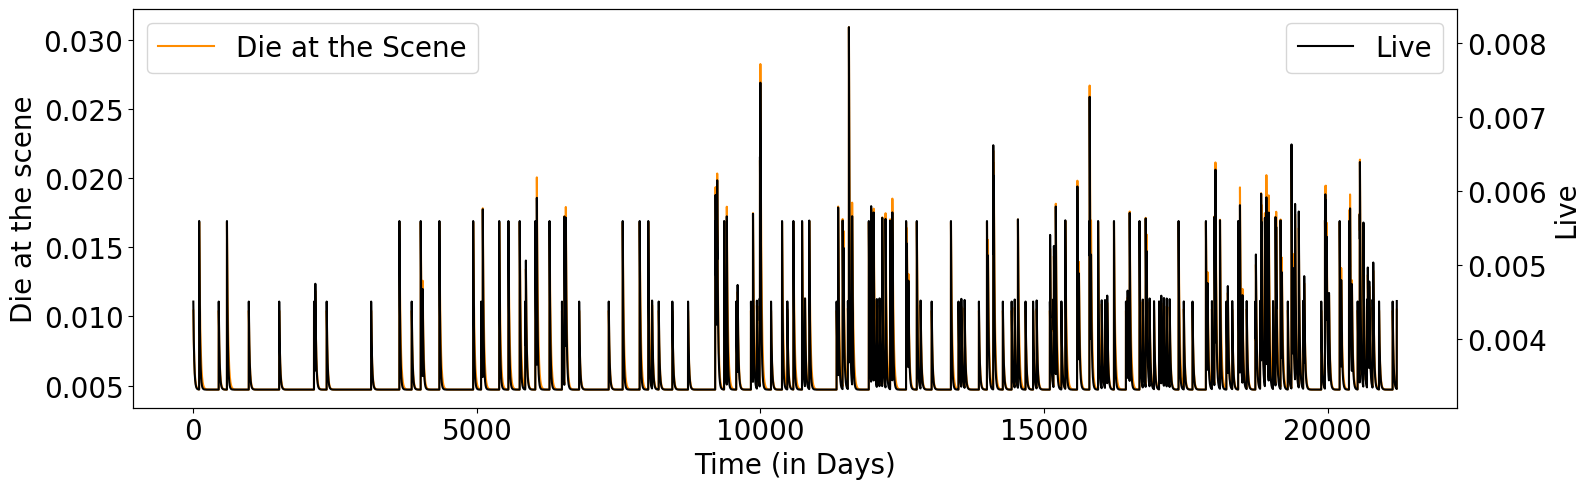

In [113]:
times1 = ta #die at the scene
times2 = tb #live
t = np.arange(1, T, 1)

intensity_on = np.zeros(len(t)) #intensity of dying at the scene
intensity_off = np.zeros(len(t)) # intensity of living



for i in range(len(t)):
    intensity_on[i] = baseline[0]
    for j in range(len(times1)):
        if t[i] > times1[j]:
            intensity_on[i] += adj[0,0] * decay[0,0]* np.exp(-decay[0,0] * (t[i] - times1[j]))
    for j in range(len(times2)):
        if t[i] > times2[j]:
            intensity_on[i] += adj[0,1]*decay[0,1]*np.exp(-decay[0,1]*(t[i]-times2[j]))
    

for i in range(len(t)):
    intensity_off[i] = baseline[1]
    for j in range(len(times2)):
        if t[i] > times2[j]:
            intensity_off[i] += adj[1,1] * decay[1,1]* np.exp(-decay[1,1] * (t[i] - times2[j]))
    for j in range(len(times1)):
        if t[i] > times1[j]:
            intensity_off[i] += adj[1,0]*decay[1,0]*np.exp(-decay[1,0]*(t[i]-times1[j]))



fig, ax = plt.subplots(figsize = (16,5))
ax2 = plt.twinx()

ax2.plot(t, intensity_off, color = 'black',  label = 'Live') # live intensity
ax.plot(t, intensity_on, color = 'darkorange', label = 'Die at the Scene') #die at the scene intensity


ax.set_xlabel('Time (in Days)', fontsize=20)
ax.set_ylabel('Die at the scene', fontsize=20)
ax2.set_ylabel('Live', fontsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax2.tick_params(axis='y', labelsize=20) 
ax.legend(loc = 'upper left', fontsize=20)
ax2.legend(loc = 'upper right', fontsize=20)
plt.tight_layout()
plt.savefig('coupled_intensity_real_data.eps')
plt.show()

### Residual analysis

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


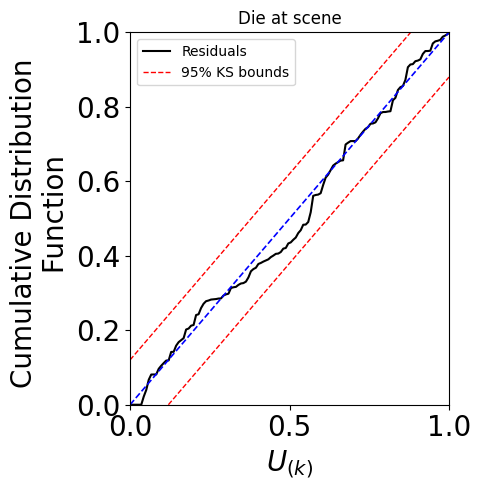

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


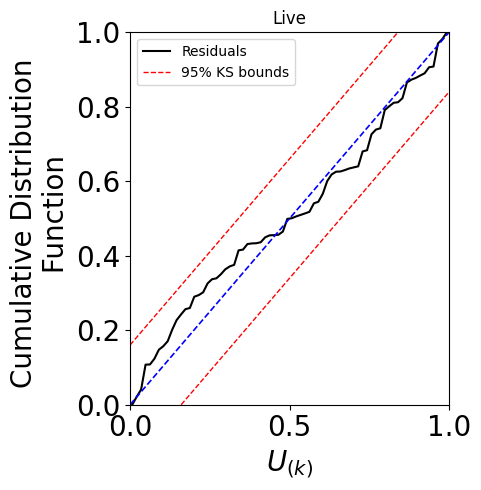

In [154]:

def compensator_A(t_eval, ta, tb, baseline, adj, decay):
    val = baseline[0] * t_eval
    for tj in ta:
        if tj < t_eval:
            val += adj[0, 0] * (1 - np.exp(-decay[0, 0] * (t_eval - tj)))
    for tj in tb:
        if tj < t_eval:
            val += adj[0, 1] * (1 - np.exp(-decay[0, 1] * (t_eval - tj)))
    return val

def compensator_B(t_eval, ta, tb, baseline, adj, decay):
    val = baseline[1] * t_eval
    for tj in ta:
        if tj < t_eval:
            val += adj[1, 0] * (1 - np.exp(-decay[1, 0] * (t_eval - tj)))
    for tj in tb:
        if tj < t_eval:
            val += adj[1, 1] * (1 - np.exp(-decay[1, 1] * (t_eval - tj)))
    return val

# transform event times to Uniform(0,1)
def thinning_transforms(event_times, comp_func, ta, tb, baseline, adj, decay):
    taus = np.array([comp_func(t, ta, tb, baseline, adj, decay) for t in event_times])
    incr = np.diff(np.insert(taus, 0, 0.0))
    u = 1 - np.exp(-incr)   # should be iid Uniform(0,1)
    return u

# KS plot for Uniform(0,1) 
def ks_plot_uniform(u, title='', fig_title=''):
    n = len(u)
    u_sorted = np.sort(u)

    # expected Uniform order statistic locations
    theo = (np.arange(1, n + 1) - 0.5) / n

    # approximate 95% KS bounds
    c = 1.36 / np.sqrt(n)
    lower = np.clip(theo - c, 0, 1)
    upper = np.clip(theo + c, 0, 1)

    plt.figure(figsize=(5, 5))

    # observed line
    plt.plot(theo, u_sorted, 'k', label = 'Residuals')

    # middle line starts from 0 and goes to 1
    plt.plot([0, 1], [0, 1], 'b--', lw=1.2)

    # parallel lines that intersect the axes
    # lower line: from (c, 0) to (1, 1-c)
    # upper line: from (0, c) to (1-c, 1)
    plt.plot([c, 1], [0, 1 - c], 'r--', lw=1.0, label='95% KS bounds')
    plt.plot([0, 1 - c], [c, 1], 'r--', lw=1.0)
    plt.tick_params(axis='x', labelsize=20)
    plt.tick_params(axis='y', labelsize=20)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("$U_{(k)}$", fontsize = 20)
    plt.ylabel("Cumulative Distribution \n Function", fontsize = 20)
    plt.legend(fontsize = 10)
    if title:
        plt.title(title)

    plt.tight_layout()

    if fig_title:
        plt.savefig(fig_title, bbox_inches='tight')

    plt.show()

u_A = thinning_transforms(ta, compensator_A, ta, tb, baseline, adj, decay)
u_B = thinning_transforms(tb, compensator_B, ta, tb, baseline, adj, decay)

ks_plot_uniform(u_A, title="Die at scene", fig_title='die_at_scene_all.eps')
ks_plot_uniform(u_B, title="Live", fig_title = 'die_after_all.eps')